I. Установка зависимостей, библиотек и загрузка корпуса данных

In [ ]:
!pip install kaggle
import kagglehub


In [ ]:
!pip install wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

COLORS = {
    'human': '#4C72B0',
    'ai':    '#DD8452',
    'accent': '#55A868',
    'bg': '#F8F9FA'
}

print("✅ Библиотеки установлены")

✅ Библиотеки установлены


In [ ]:
path = kagglehub.dataset_download("alitaqishah/ai-vs-human-text-classification-dataset-2026")

Using Colab cache for faster access to the 'ai-vs-human-text-classification-dataset-2026' dataset.


In [ ]:
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/ai-vs-human-text-classification-dataset-2026


In [ ]:
data = pd.read_csv('/root/.cache/kagglehub/datasets/alitaqishah/ai-vs-human-text-classification-dataset-2026/versions/1/ai_vs_human_text_2026.csv',index_col=0)


 II. Обзор корпуса данных

In [ ]:
print(data.head())

             text_id  label source_model    domain  \
Unnamed: 0                                           
0           TXT_0001  human        human    social   
1           TXT_0002  human        human    social   
2           TXT_0003     ai   gemini-2.0      news   
3           TXT_0004  human        human  academic   
4           TXT_0005     ai       gpt-4o  academic   

                                                 text_content  \
Unnamed: 0                                                      
0           can we talk about gene editing ethics for a se...   
1           update on election integrity concerns: it's co...   
2           Analysts are closely watching developments rel...   
3           This paper examines genomic research breakthro...   
4           Existing literature on student debt crisis has...   

                                      topic_hint  word_count  \
Unnamed: 0                                                     
0                            gene edi

In [ ]:
print(data.head(10))

             text_id  label source_model    domain  \
Unnamed: 0                                           
0           TXT_0001  human        human    social   
1           TXT_0002  human        human    social   
2           TXT_0003     ai   gemini-2.0      news   
3           TXT_0004  human        human  academic   
4           TXT_0005     ai       gpt-4o  academic   
5           TXT_0006     ai       gpt-4o  academic   
6           TXT_0007  human        human  academic   
7           TXT_0008  human        human      news   
8           TXT_0009  human        human      news   
9           TXT_0010     ai       gpt-4o  academic   

                                                 text_content  \
Unnamed: 0                                                      
0           can we talk about gene editing ethics for a se...   
1           update on election integrity concerns: it's co...   
2           Analysts are closely watching developments rel...   
3           This paper exa

In [ ]:
# Типы данных, количество непустых значений

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   text_id              2000 non-null   object 
 1   label                2000 non-null   object 
 2   source_model         2000 non-null   object 
 3   domain               2000 non-null   object 
 4   text_content         2000 non-null   object 
 5   topic_hint           2000 non-null   object 
 6   word_count           2000 non-null   int64  
 7   avg_sentence_length  2000 non-null   float64
 8   generation_method    2000 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 156.2+ KB
None


In [ ]:
# (количество_строк, количество_столбцов)

In [ ]:
print(data.shape)

(2000, 9)


In [ ]:
#  Описательная статистика. Для числовых данных полезно посмотреть базовую статистику:

In [ ]:
print(data.describe())

        word_count  avg_sentence_length
count  2000.000000          2000.000000
mean     37.006500            12.739950
std       8.892975             2.846465
min      19.000000             6.500000
25%      28.000000            10.200000
50%      38.000000            13.000000
75%      45.000000            15.300000
max      52.000000            18.500000


In [ ]:
#  Проверка на пропущенные значения

In [ ]:
print(data.isnull().sum())  # Сколько пропусков в каждом столбце

text_id                0
label                  0
source_model           0
domain                 0
text_content           0
topic_hint             0
word_count             0
avg_sentence_length    0
generation_method      0
dtype: int64


In [ ]:
df = pd.DataFrame(data)
df.to_csv('/root/.cache/kagglehub/datasets/alitaqishah/ai-vs-human-text-classification-dataset-2026/versions/1/ai_vs_human_text_2026.csv',index=False)

In [ ]:
pd.read_csv('/root/.cache/kagglehub/datasets/alitaqishah/ai-vs-human-text-classification-dataset-2026/versions/1/ai_vs_human_text_2026.csv').head()

,text_id,label,source_model,domain,text_content,topic_hint,word_count,avg_sentence_length,generation_method
0,TXT_0001,human,human,social,can we talk about gene editing ethics for a se...,gene editing ethics,27,13.5,template+human_variation
1,TXT_0002,human,human,social,update on election integrity concerns: it's co...,election integrity concerns,20,10.0,template+human_variation
2,TXT_0003,ai,gemini-2.0,news,Analysts are closely watching developments rel...,climate change adaptation strategies,39,13.0,style_simulation
3,TXT_0004,human,human,academic,This paper examines genomic research breakthro...,genomic research breakthroughs,49,16.3,template+human_variation
4,TXT_0005,ai,gpt-4o,academic,Existing literature on student debt crisis has...,student debt crisis,42,10.8,style_simulation


In [ ]:
print(f"Shape       : {df.shape}")
print(f"Columns     : {list(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

Shape       : (2000, 9)
Columns     : ['text_id', 'label', 'source_model', 'domain', 'text_content', 'topic_hint', 'word_count', 'avg_sentence_length', 'generation_method']
Memory usage: 1427.2 KB


In [ ]:
print("=== Data Types & Null Check ===")
print(df.dtypes)
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

=== Data Types & Null Check ===
text_id                 object
label                   object
source_model            object
domain                  object
text_content            object
topic_hint              object
word_count               int64
avg_sentence_length    float64
generation_method       object
dtype: object

Null values:
text_id                0
label                  0
source_model           0
domain                 0
text_content           0
topic_hint             0
word_count             0
avg_sentence_length    0
generation_method      0
dtype: int64

Duplicate rows: 0


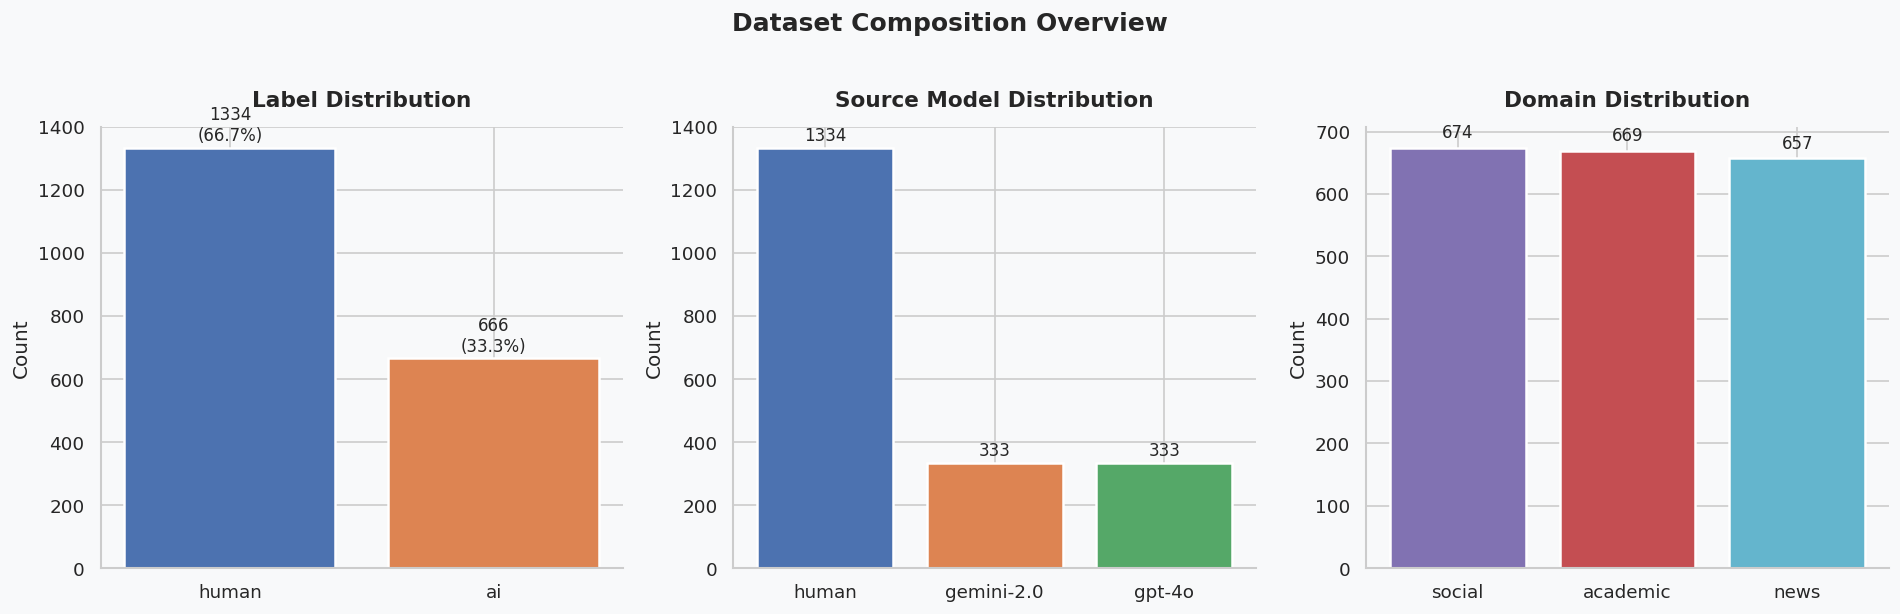


⚠️  Class Imbalance Note: Human=1334 (66.7%) | AI=666 (33.3%)
   → Consider class_weight='balanced' or oversampling when training classifiers.


In [ ]:
# Распределение классов
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(COLORS['bg'])

# Классы
label_counts = df['label'].value_counts()
bars = axes[0].bar(label_counts.index, label_counts.values,
                   color=[COLORS['human'], COLORS['ai']], edgecolor='white', linewidth=1.5)
axes[0].set_title('Label Distribution', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Count')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)

# Распределение по источникам данных для корпуса
model_counts = df['source_model'].value_counts()
colors_model = [COLORS['human'], COLORS['ai'], COLORS['accent']]
axes[1].bar(model_counts.index, model_counts.values,
            color=colors_model, edgecolor='white', linewidth=1.5)
axes[1].set_title('Source Model Distribution', fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel('Count')
for i, (idx, val) in enumerate(model_counts.items()):
    axes[1].text(i, val + 10, str(val), ha='center', va='bottom', fontsize=10)

# Тематические домены и распределение
domain_counts = df['domain'].value_counts()
axes[2].bar(domain_counts.index, domain_counts.values,
            color=['#8172B2', '#C44E52', '#64B5CD'], edgecolor='white', linewidth=1.5)
axes[2].set_title('Domain Distribution', fontsize=13, fontweight='bold', pad=12)
axes[2].set_ylabel('Count')
for i, (idx, val) in enumerate(domain_counts.items()):
    axes[2].text(i, val + 10, str(val), ha='center', va='bottom', fontsize=10)

for ax in axes:
    ax.set_facecolor(COLORS['bg'])
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Dataset Composition Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n⚠️  Class Imbalance Note: Human={label_counts['human']} ({label_counts['human']/len(df)*100:.1f}%) | AI={label_counts['ai']} ({label_counts['ai']/len(df)*100:.1f}%)")
print("   → Consider class_weight='balanced' or oversampling when training classifiers.")

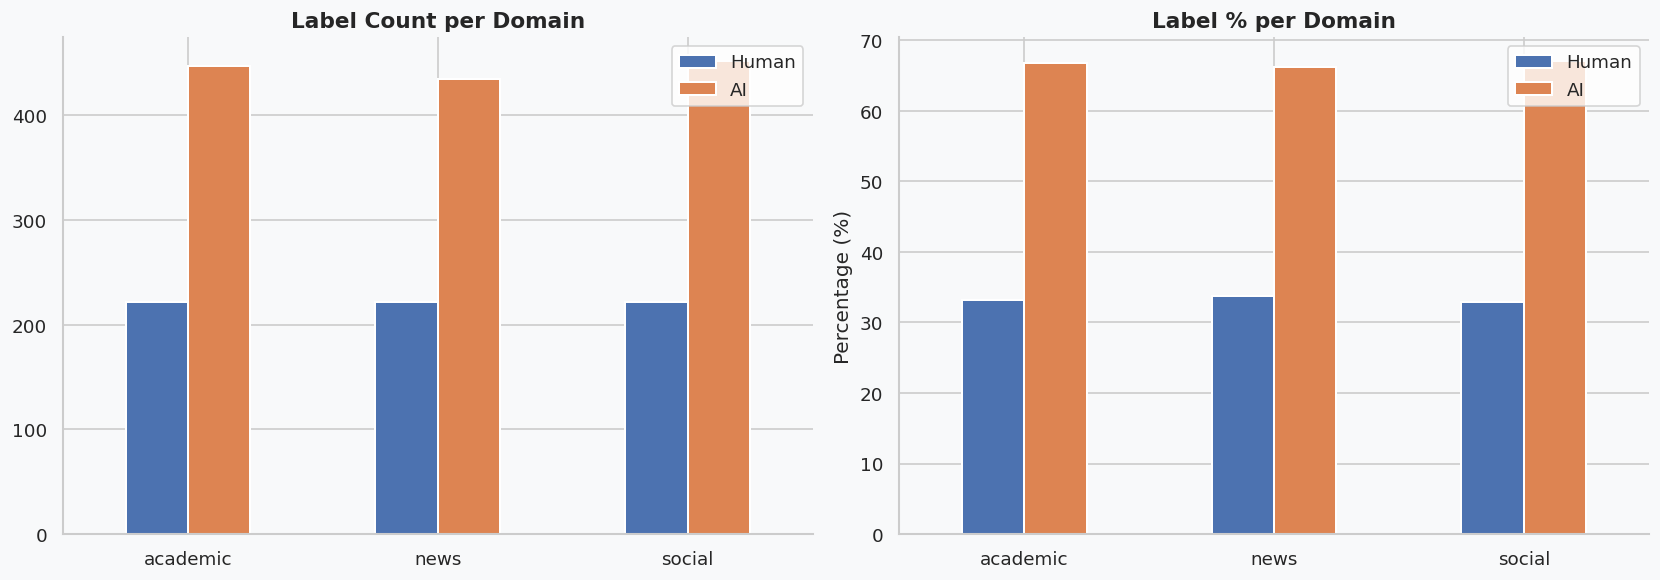

In [ ]:
# Детализация по тематическим меткам
ct = pd.crosstab(df['domain'], df['label'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])

ct.plot(kind='bar', ax=axes[0], color=[COLORS['human'], COLORS['ai']],
        edgecolor='white', linewidth=1.2)
axes[0].set_title('Label Count per Domain', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Human', 'AI'])
axes[0].set_facecolor(COLORS['bg'])
axes[0].spines[['top','right']].set_visible(False)

ct_pct.plot(kind='bar', ax=axes[1], color=[COLORS['human'], COLORS['ai']],
            edgecolor='white', linewidth=1.2)
axes[1].set_title('Label % per Domain', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Human', 'AI'])
axes[1].set_facecolor(COLORS['bg'])
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

**III. Разведочный анализ**

In [ ]:
# Статистика количества слов и длины предложений
print("=== Word Count Statistics by Label ===")
print(df.groupby('label')['word_count'].describe().round(2))
print("\n=== Avg Sentence Length by Label ===")
print(df.groupby('label')['avg_sentence_length'].describe().round(2))

=== Word Count Statistics by Label ===
        count   mean   std   min   25%   50%   75%   max
label                                                   
ai      666.0  38.00  7.01  23.0  35.0  39.0  44.0  50.0
human  1334.0  36.51  9.66  19.0  27.0  36.0  46.0  52.0

=== Avg Sentence Length by Label ===
        count   mean   std  min   25%   50%   75%   max
label                                                  
ai      666.0  13.27  2.26  8.7  12.0  13.0  15.0  18.5
human  1334.0  12.47  3.06  6.5  10.0  13.0  15.3  17.3


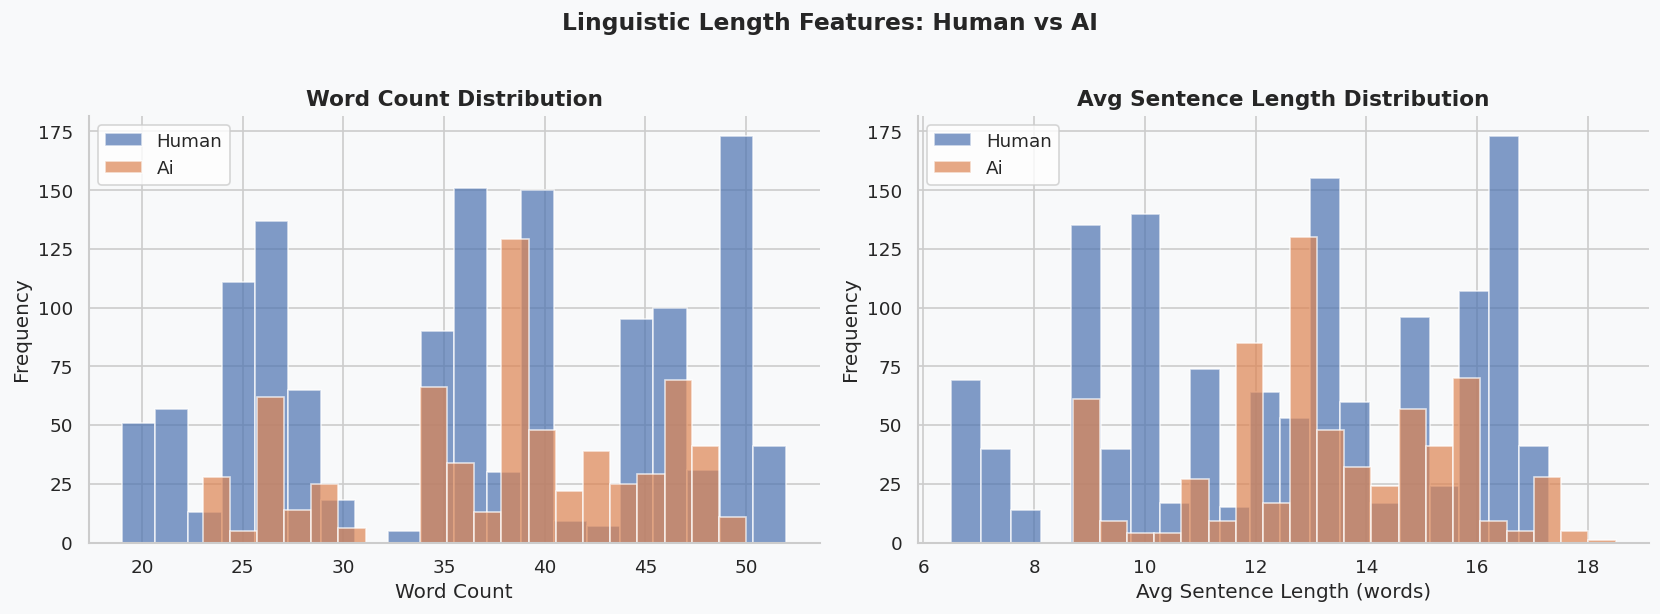

In [ ]:
# Распределение числа слов у ИИ и людей
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])

for label, color in [('human', COLORS['human']), ('ai', COLORS['ai'])]:
    subset = df[df['label'] == label]['word_count']
    axes[0].hist(subset, bins=20, alpha=0.7, color=color, label=label.capitalize(), edgecolor='white')

axes[0].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_facecolor(COLORS['bg'])
axes[0].spines[['top','right']].set_visible(False)

# Средняя длина предложений и их распределение
for label, color in [('human', COLORS['human']), ('ai', COLORS['ai'])]:
    subset = df[df['label'] == label]['avg_sentence_length']
    axes[1].hist(subset, bins=20, alpha=0.7, color=color, label=label.capitalize(), edgecolor='white')

axes[1].set_title('Avg Sentence Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Sentence Length (words)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_facecolor(COLORS['bg'])
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Linguistic Length Features: Human vs AI', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


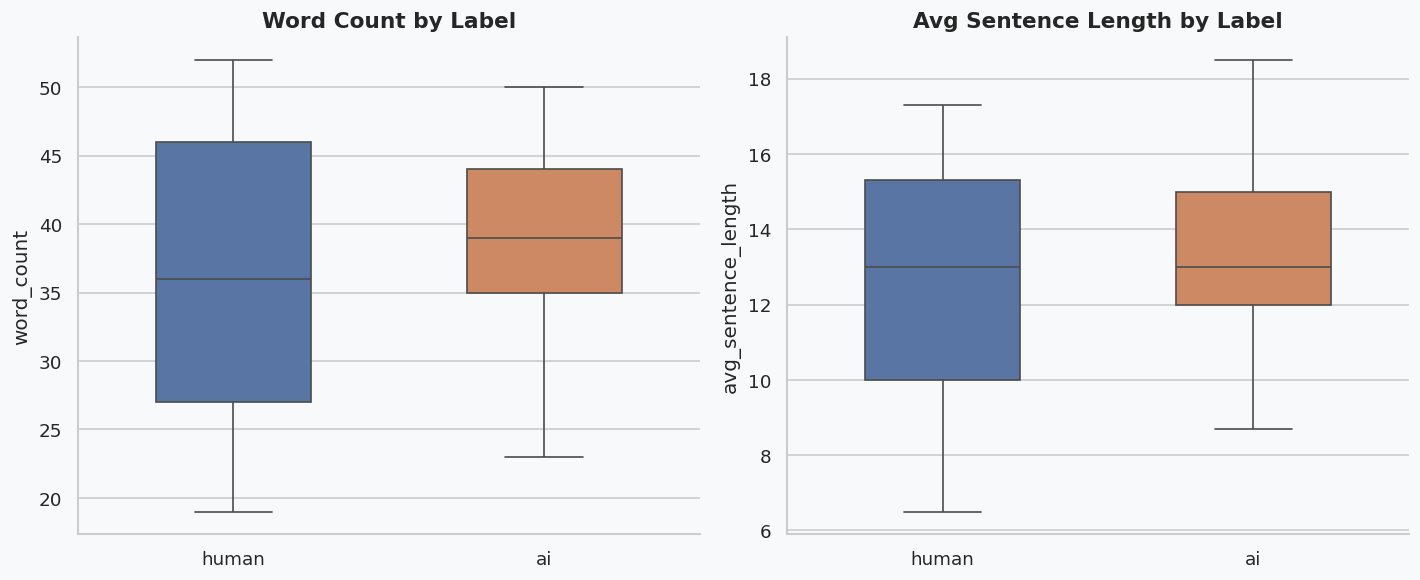

In [ ]:
# Сравнение распределительных данных
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(COLORS['bg'])

sns.boxplot(data=df, x='label', y='word_count', palette=[COLORS['human'], COLORS['ai']],
            ax=axes[0], width=0.5)
axes[0].set_title('Word Count by Label', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_facecolor(COLORS['bg'])
axes[0].spines[['top','right']].set_visible(False)

sns.boxplot(data=df, x='label', y='avg_sentence_length', palette=[COLORS['human'], COLORS['ai']],
            ax=axes[1], width=0.5)
axes[1].set_title('Avg Sentence Length by Label', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_facecolor(COLORS['bg'])
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

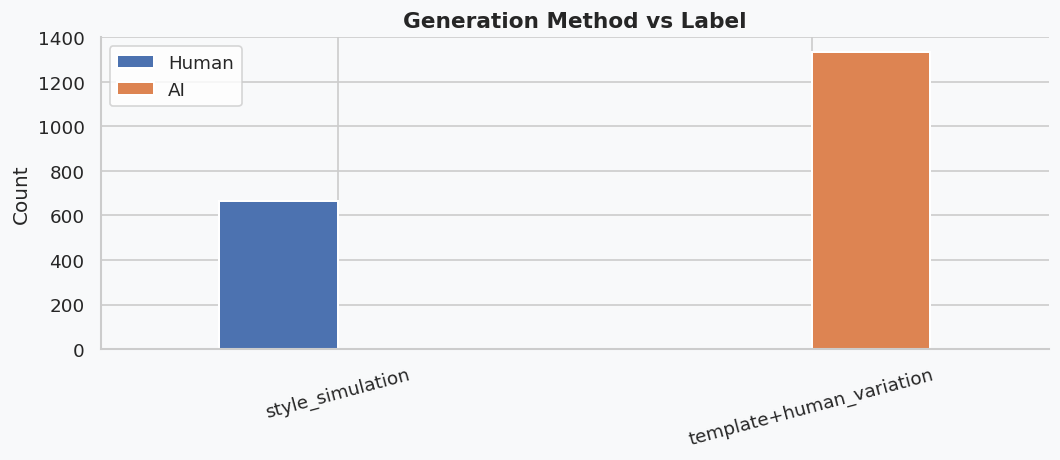

In [ ]:
# Детализация по методам генерации
gen_ct = pd.crosstab(df['generation_method'], df['label'])

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(COLORS['bg'])
gen_ct.plot(kind='bar', ax=ax, color=[COLORS['human'], COLORS['ai']],
            edgecolor='white', linewidth=1.2)
ax.set_title('Generation Method vs Label', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=15)
ax.legend(['Human', 'AI'])
ax.set_facecolor(COLORS['bg'])
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# IV. Тематический анализ

In [ ]:
# Частотность тем
topic_counts = df['topic_hint'].value_counts()
print(f"Total unique topics: {len(topic_counts)}")
print("\nTop 10 topics by frequency:")
print(topic_counts.head(10))

Total unique topics: 30

Top 10 topics by frequency:
topic_hint
genomic research breakthroughs          82
aging population challenges             80
artificial intelligence regulation      78
biodiversity loss                       77
space exploration milestones            76
mental health awareness campaigns       73
renewable energy adoption               73
climate change adaptation strategies    72
gene editing ethics                     72
education reform debates                72
Name: count, dtype: int64


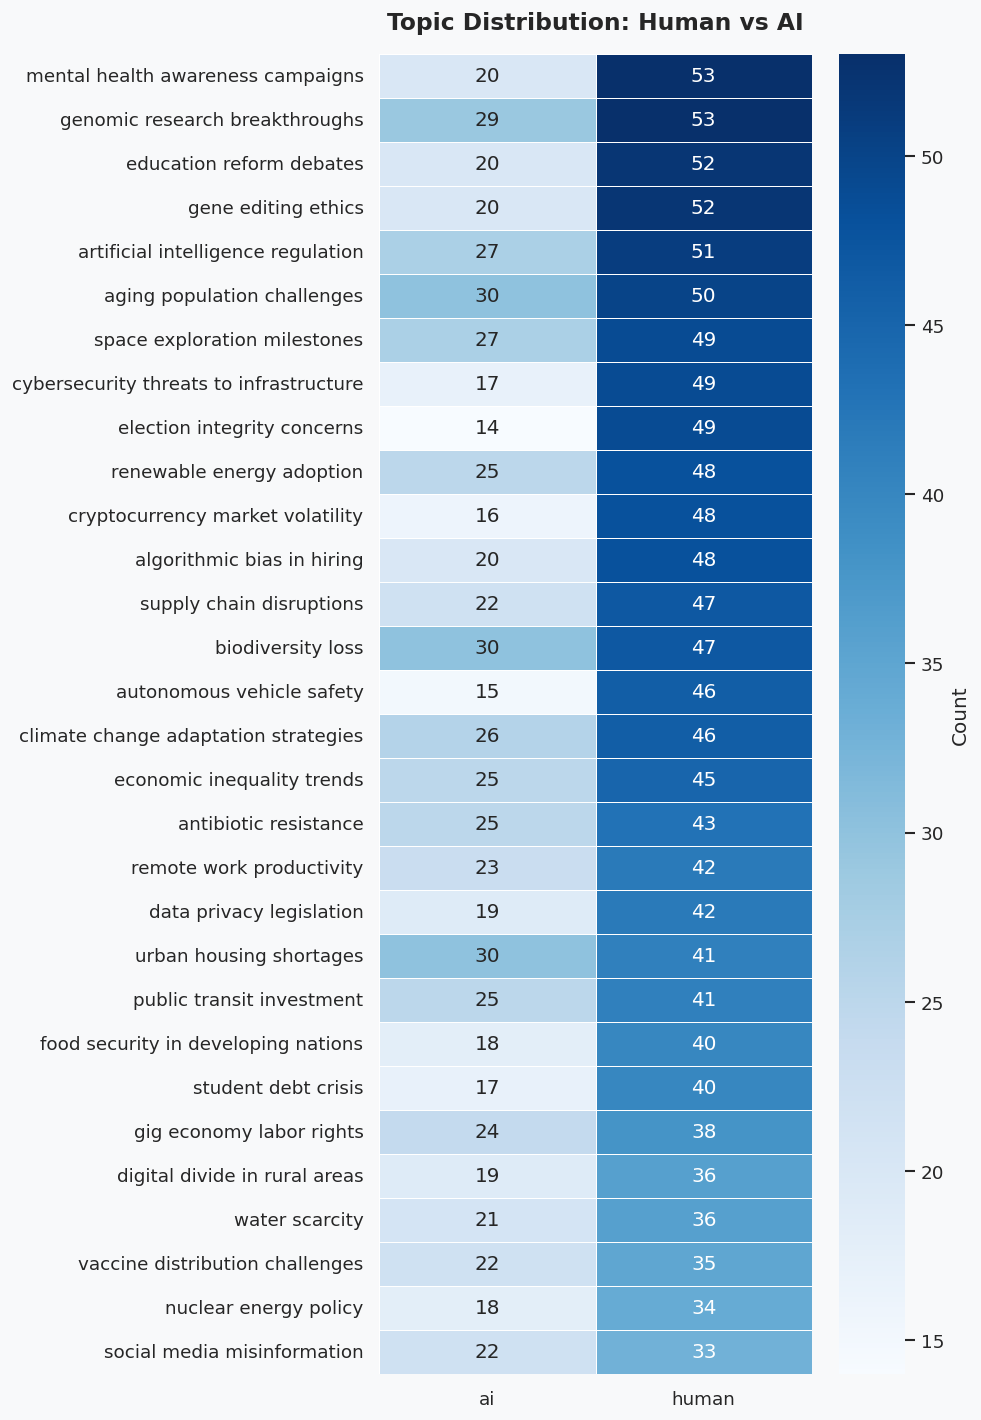

In [ ]:
# Распредление тем по классам
topic_label = pd.crosstab(df['topic_hint'], df['label'])
topic_label = topic_label.sort_values('human', ascending=False)

fig, ax = plt.subplots(figsize=(8, 12))
fig.patch.set_facecolor(COLORS['bg'])
sns.heatmap(topic_label, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Count'})
ax.set_title('Topic Distribution: Human vs AI', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

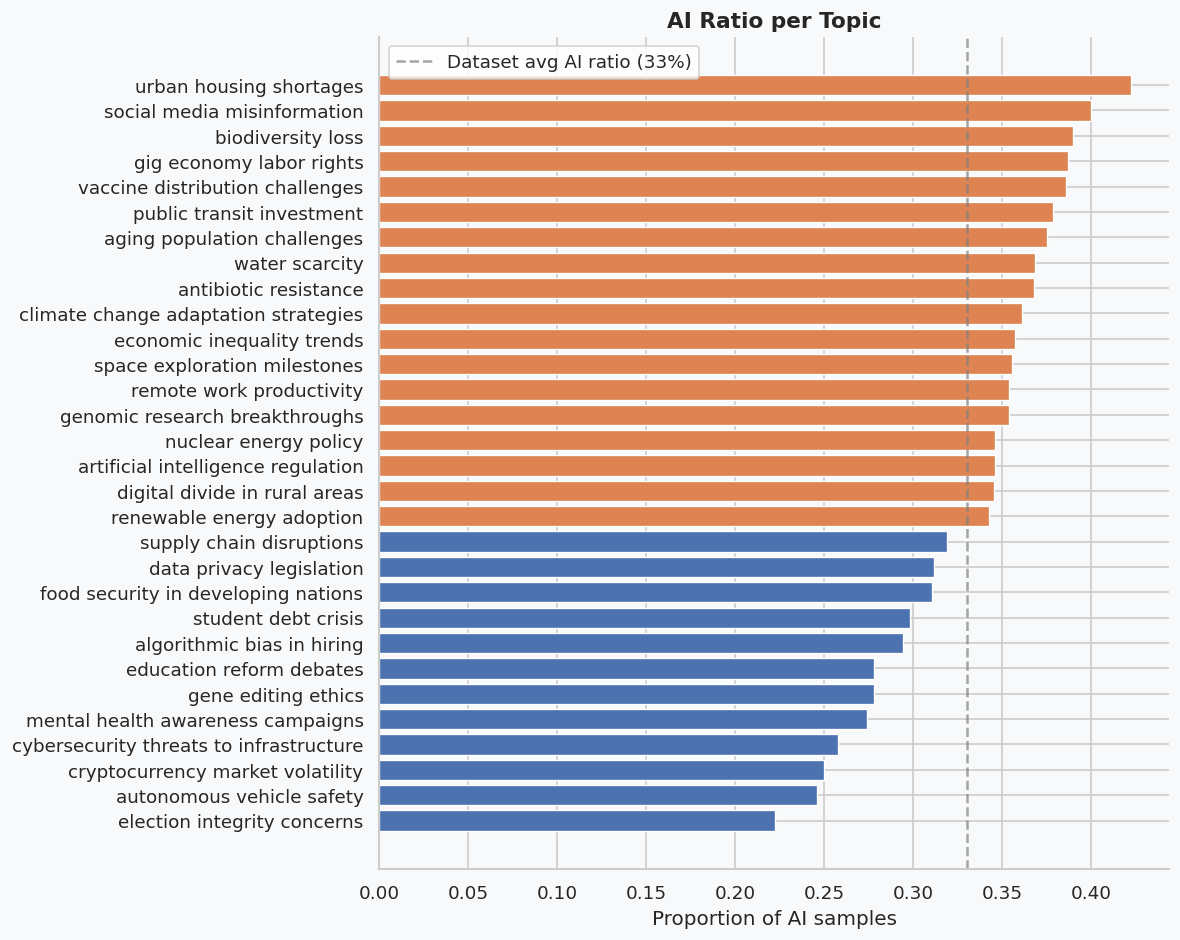

In [ ]:
# Рейтинг тем по плотности ИИ
topic_label['ai_ratio'] = topic_label['ai'] / (topic_label['ai'] + topic_label['human'])
topic_label_sorted = topic_label.sort_values('ai_ratio', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(COLORS['bg'])
bars = ax.barh(topic_label_sorted.index, topic_label_sorted['ai_ratio'],
               color=[COLORS['ai'] if v > 0.33 else COLORS['human'] for v in topic_label_sorted['ai_ratio']],
               edgecolor='white', linewidth=0.8)
ax.axvline(0.33, color='gray', linestyle='--', alpha=0.7, label='Dataset avg AI ratio (33%)')
ax.set_title('AI Ratio per Topic', fontsize=13, fontweight='bold')
ax.set_xlabel('Proportion of AI samples')
ax.set_facecolor(COLORS['bg'])
ax.spines[['top','right']].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

# V. Языковые закономерности

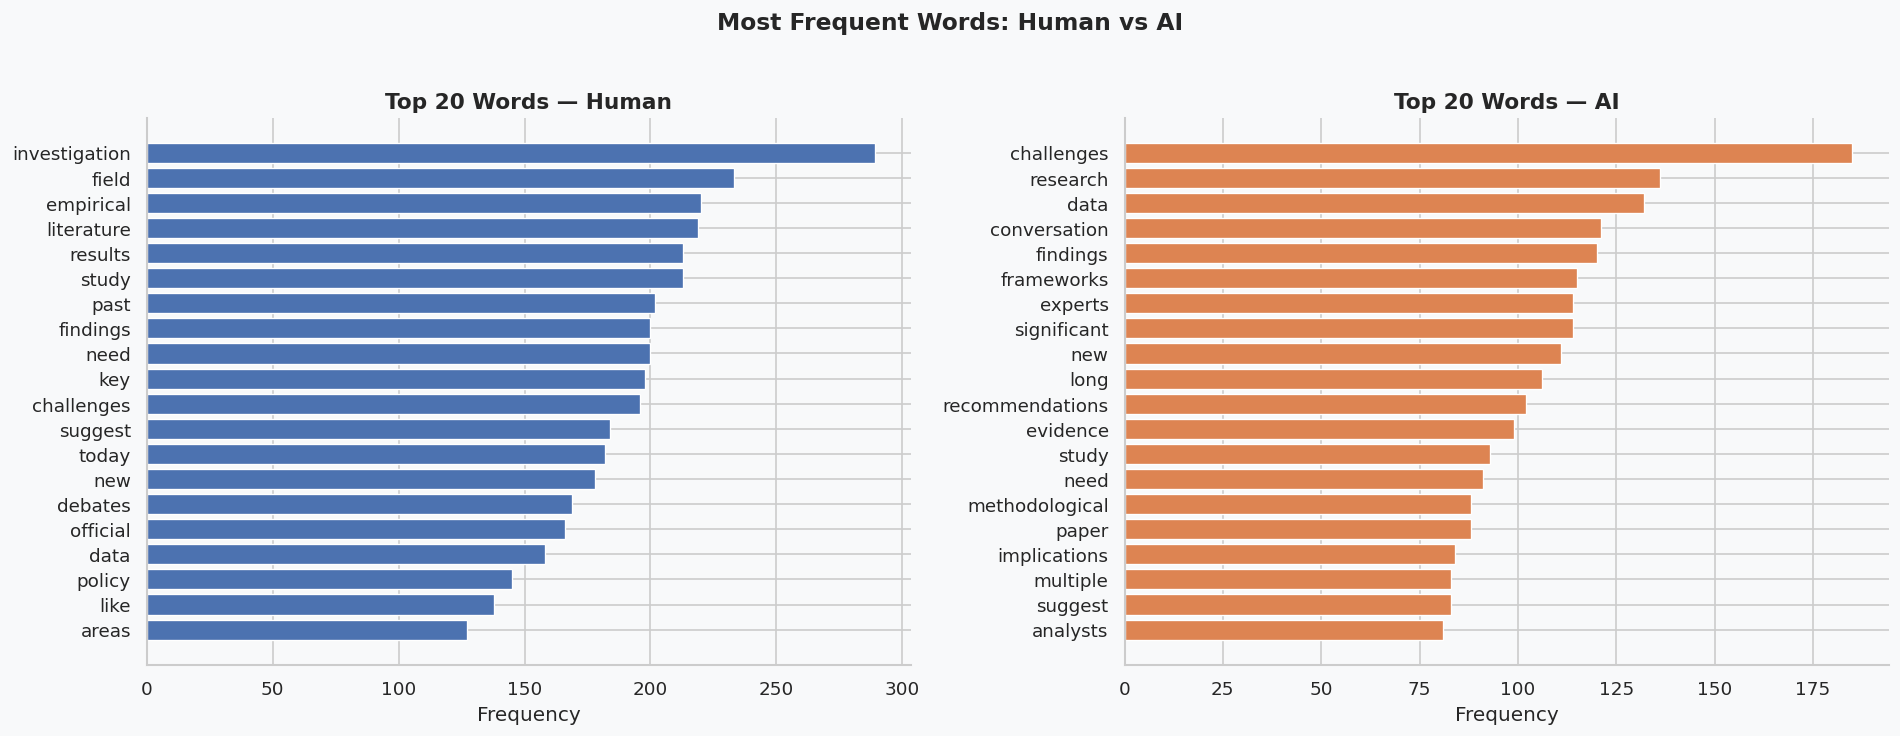

In [ ]:
# Векторизуем данные и выводим языковые закономерности
from sklearn.feature_extraction.text import CountVectorizer

def get_top_words(texts, n=20, ngram=(1,1)):
    vec = CountVectorizer(stop_words='english', ngram_range=ngram, max_features=5000)
    X = vec.fit_transform(texts)
    word_freq = dict(zip(vec.get_feature_names_out(), X.toarray().sum(axis=0)))
    return sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:n]

human_texts = df[df['label'] == 'human']['text_content']
ai_texts    = df[df['label'] == 'ai']['text_content']

human_top = get_top_words(human_texts)
ai_top    = get_top_words(ai_texts)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(COLORS['bg'])

for ax, top_words, label, color in [
    (axes[0], human_top, 'Human', COLORS['human']),
    (axes[1], ai_top,    'AI',    COLORS['ai'])
]:
    words, counts = zip(*top_words)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='white', linewidth=0.8)
    ax.set_title(f'Top 20 Words — {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.set_facecolor(COLORS['bg'])
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Most Frequent Words: Human vs AI', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

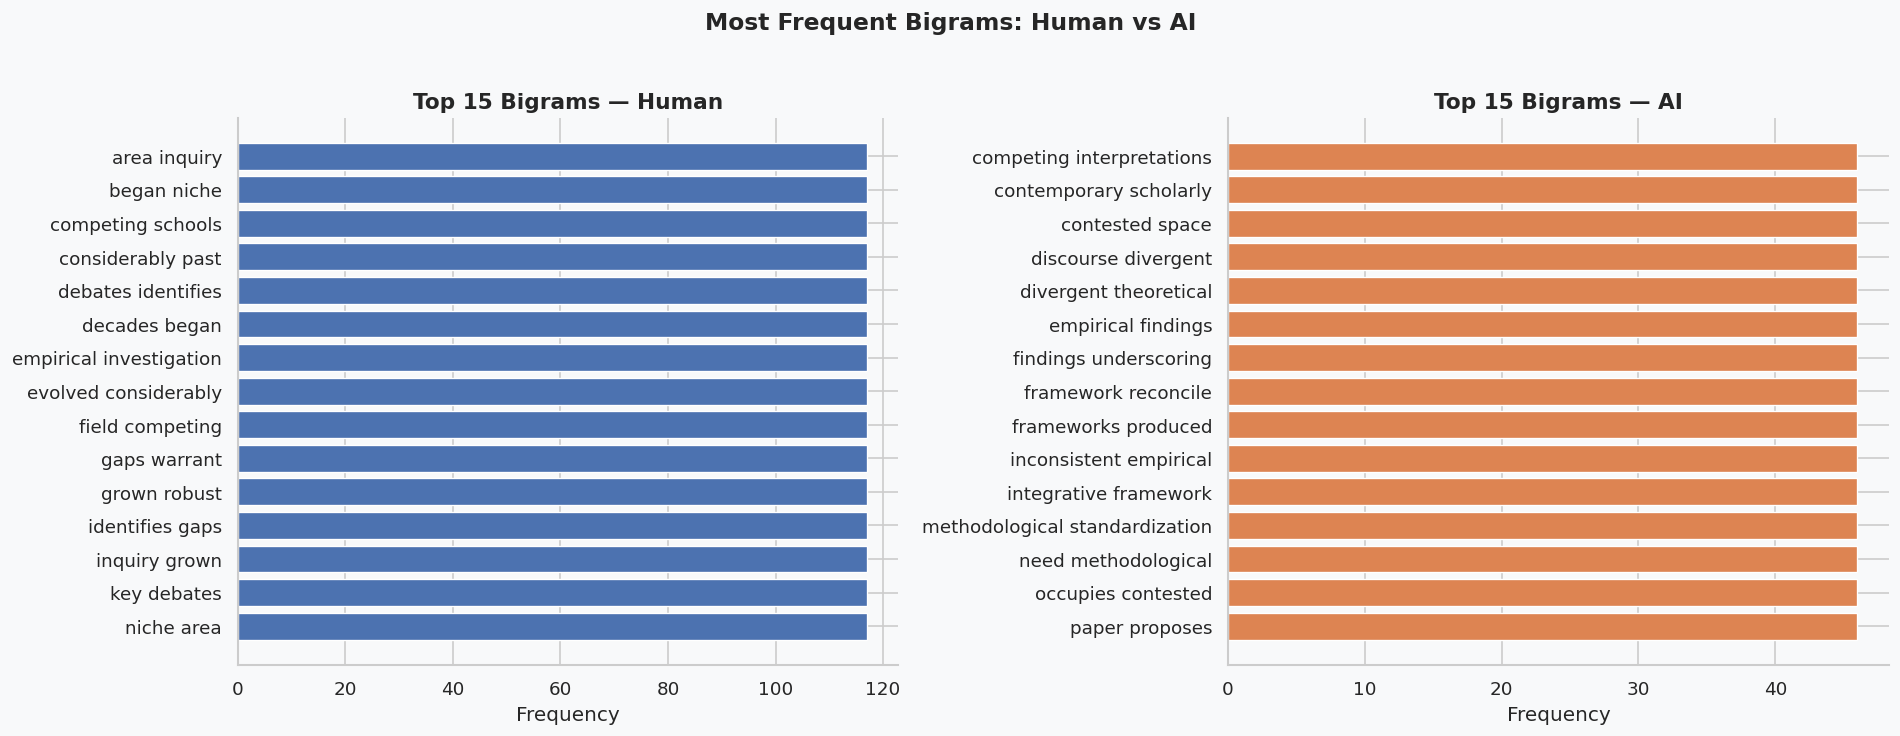

In [ ]:
# Сравнение биграмм
human_bigrams = get_top_words(human_texts, n=15, ngram=(2,2))
ai_bigrams    = get_top_words(ai_texts, n=15, ngram=(2,2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(COLORS['bg'])

for ax, bigrams, label, color in [
    (axes[0], human_bigrams, 'Human', COLORS['human']),
    (axes[1], ai_bigrams,    'AI',    COLORS['ai'])
]:
    words, counts = zip(*bigrams)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='white', linewidth=0.8)
    ax.set_title(f'Top 15 Bigrams — {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.set_facecolor(COLORS['bg'])
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Most Frequent Bigrams: Human vs AI', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

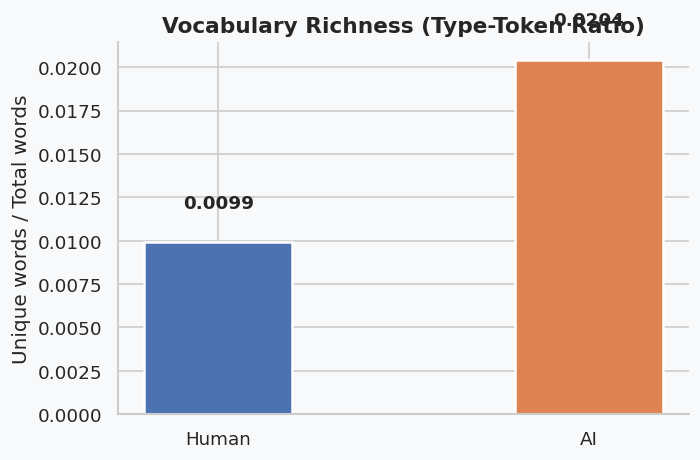

Human vocab richness: 0.0099
AI vocab richness   : 0.0204


In [ ]:
# Разнообразие и обогащенность лексики
def vocab_richness(texts):
    all_words = ' '.join(texts).lower().split()
    return len(set(all_words)) / len(all_words)

human_richness = vocab_richness(human_texts)
ai_richness    = vocab_richness(ai_texts)

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor(COLORS['bg'])
bars = ax.bar(['Human', 'AI'], [human_richness, ai_richness],
              color=[COLORS['human'], COLORS['ai']], edgecolor='white', linewidth=1.5, width=0.4)
for bar, val in zip(bars, [human_richness, ai_richness]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Vocabulary Richness (Type-Token Ratio)', fontsize=13, fontweight='bold')
ax.set_ylabel('Unique words / Total words')
ax.set_facecolor(COLORS['bg'])
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
print(f"Human vocab richness: {human_richness:.4f}")
print(f"AI vocab richness   : {ai_richness:.4f}")

# VI. Бенчмарк и запуск базовой модели

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, roc_curve)

# Энкодинг
df['label_enc'] = (df['label'] == 'ai').astype(int)

X = df['text_content']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")
print(f"Train label balance: {y_train.value_counts().to_dict()}")
print(f"Test  label balance: {y_test.value_counts().to_dict()}")

Train size : 1600
Test size  : 400
Train label balance: {0: 1067, 1: 533}
Test  label balance: {0: 267, 1: 133}


In [ ]:
# Пайплайн (TF-IDF+LogisticRegression)
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        sublinear_tf=True,
        stop_words='english'
    )),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Human', 'AI']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00       267
          AI       1.00      1.00      1.00       133

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

ROC-AUC Score: 1.0000


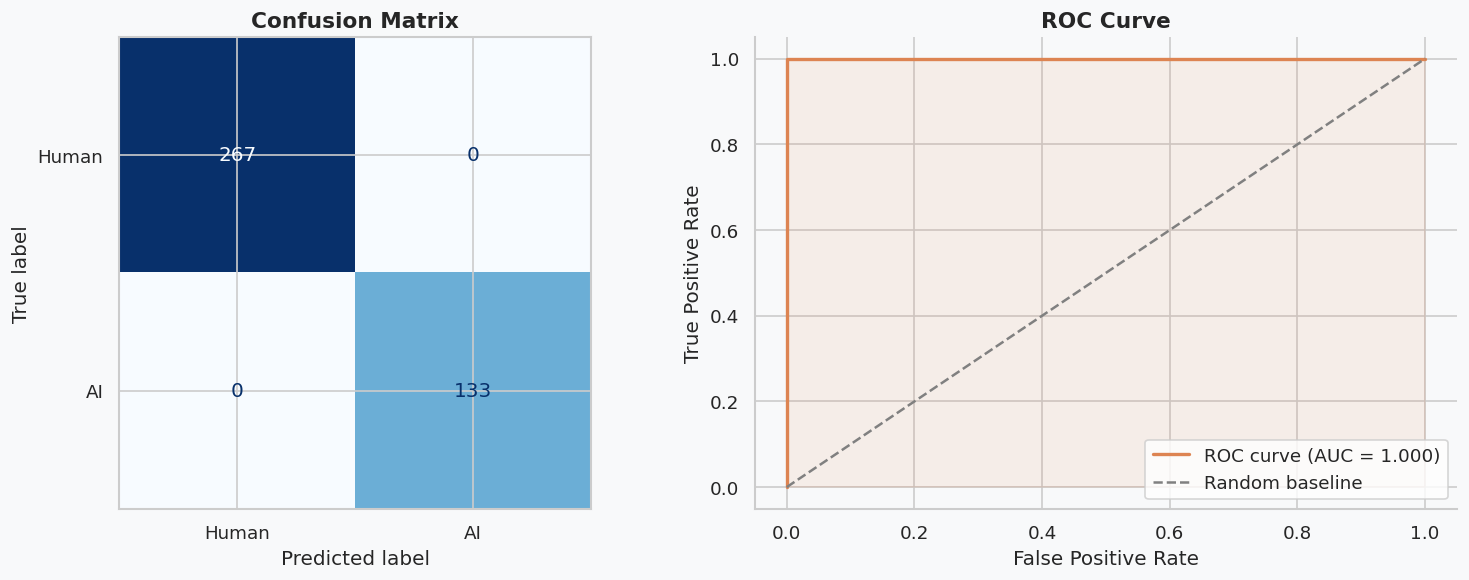

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(COLORS['bg'])

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Human', 'AI'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_facecolor(COLORS['bg'])

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color=COLORS['ai'], lw=2, label=f'ROC curve (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--', lw=1.5, label='Random baseline')
axes[1].fill_between(fpr, tpr, alpha=0.1, color=COLORS['ai'])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].set_facecolor(COLORS['bg'])
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Кросс-валидация
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1', n_jobs=-1)
print(f"5-Fold CV F1 Scores : {cv_scores.round(4)}")
print(f"Mean F1             : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-Fold CV F1 Scores : [1. 1. 1. 1. 1.]
Mean F1             : 1.0000 ± 0.0000


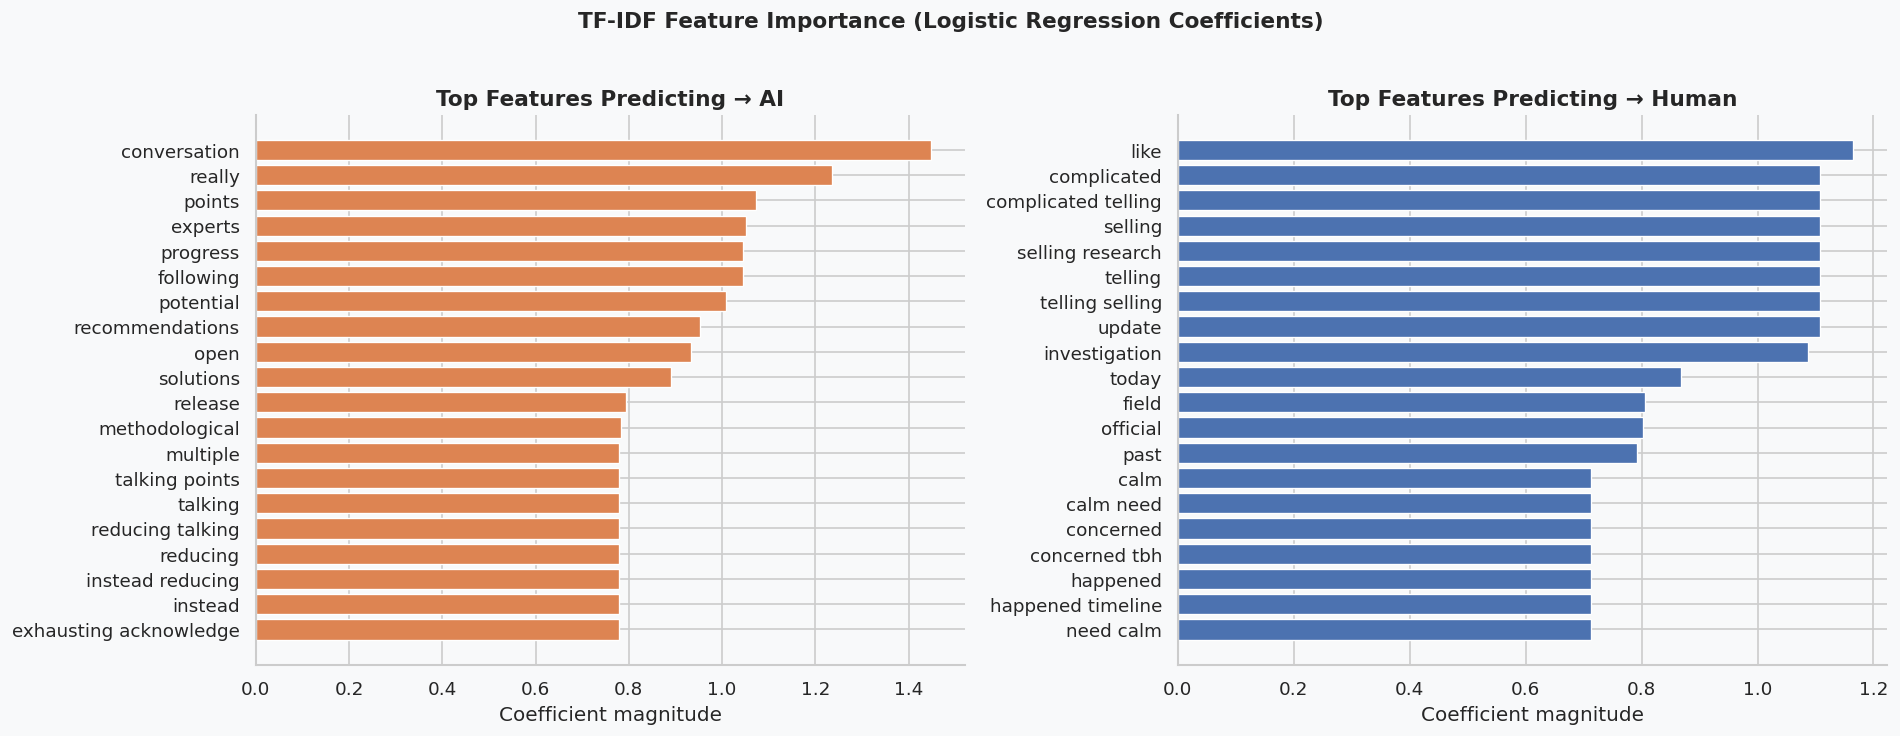

In [ ]:
# Топ предсказательных признаков
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coefs = pipeline.named_steps['clf'].coef_[0]

top_ai    = sorted(zip(coefs, feature_names), reverse=True)[:20]
top_human = sorted(zip(coefs, feature_names))[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(COLORS['bg'])

for ax, features, label, color in [
    (axes[0], top_ai,    '→ AI',    COLORS['ai']),
    (axes[1], top_human, '→ Human', COLORS['human'])
]:
    vals, words = zip(*features)
    ax.barh(words[::-1], [abs(v) for v in vals[::-1]], color=color, edgecolor='white', linewidth=0.8)
    ax.set_title(f'Top Features Predicting {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Coefficient magnitude')
    ax.set_facecolor(COLORS['bg'])
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('TF-IDF Feature Importance (Logistic Regression Coefficients)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()